# MÅL: Hente data programmatisk

* Vi trenger først å lære litt om nettverskprotokollen: HTTP
* Vi trenger å vite litt om JSON-formatet, og python dictionaries
* Vi trenger å vite litt om hva en URL er
* Vi må kunne bruke python-biblioteket `requests` og `pyjstat`


*Vi antar vi kan litt om http-protokollen, json-format og hvordan en URL er bygget opp*


### Sende http-spørring med `requests`

For å kunne sende en httpspørring må vi:
* Vite hvilken tjener vi skal sende det til (eks www.ssb.no)
* Vite *hvor* på tjeneren ressursen vi spør etter er
* Vite om det skal være en GET/PUT spørring
* Vite hvilke parametre som skal være med
* Vite om vi skal sende med noe i headeren til spørringen (API-nøkler, brukernavn og passord etc)

Når vi vet dette, kan `requests` sette sammen spørringen og sende den på riktig vis



### Bruk av `requests`

Under er typisk gang i bruk av requests -- ikke kjørbar kode, men en cheat-sheet

```python
import requests

url = #tjener OG sti på tjeneren
parametere = # Dictionary med parameternavn: verdi
headere = #Dictionary med headere felt: verdi
data_payload = #Data som skal sendes ved -- i tilfelle POST

response = requests.get(url, params = parametere, headers = headere) # GET request
response = requests.post(url, params = parametere, headers = headere, data=data_payload) # POST request

print("statuskode", response.status_code)
print("Headere (til respons)", response.headers)
print("responstype:", response.headers['content-type']) # Dersom tilgjengerlig (feks application/json)

## Data kan leses på flere måer
data = response.json() #Dersom responsdata er i jsonformat
data = response.text #Tegnkoding ordnes som regel automatisk
data = response.content.decode("latin1") # Dersom det er feil med automatisk tegnkoding




### EKSEMPEL VÆR

Vi ønsker å hente inn værmeldingen de neste 7 dagene i Ålesund

* Vi leser dokumentasjon av et gratis værtjeneste på nett: [https://open-meteo.com/en/docs#data_sources](https://open-meteo.com/en/docs#data_sources)
  


*Vi går nøyere gjennom bruk av WebAPI  som open-meteo neste uke*


In [1]:
import requests


#Lengde og breddegrad Ålesund
#https://www.latlong.net/place/lesund-norway-17299.html
lat = 62.472229
long = 6.149482

url = "https://api.open-meteo.com/v1/forecast"
parametre = {"latitude": lat, "longitude": long, "hourly": "temperature_2m"}

#Send http-spørring
response = requests.get(url, params=parametre)


In [2]:

#Vis statuskode, headere og data
print("Statuskode:", response.status_code)
print("Headere:", response.headers)
#Spesifikt: Content-Type
print("Type svar:", response.headers["content-type"])

data = response.json()
#Dersom svar ikke er json:
#data = response.text

#data

Statuskode: 200
Headere: {'Date': 'Tue, 28 Oct 2025 12:55:19 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Content-Encoding': 'deflate'}
Type svar: application/json; charset=utf-8


<Axes: xlabel='time'>

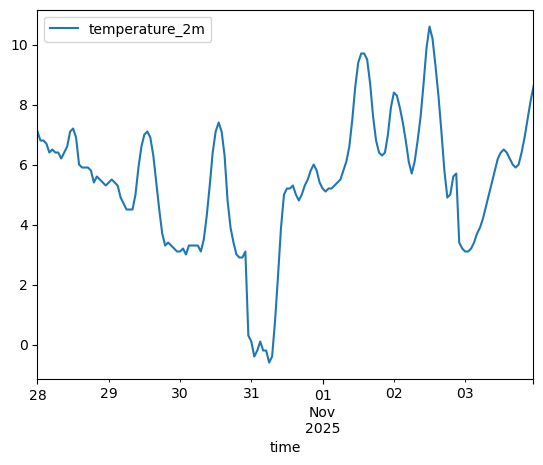

In [3]:
import pandas as pd
import json

# Les igjennom med print + keys osv .. evt skriv til fil og les i nettleser
with open("weather_data.json", 'w') as file:
    json.dump(data, file)

df = pd.DataFrame(data["hourly"])
df["time"] = pd.to_datetime(df["time"])

df.set_index("time").plot()
#Plot temperatur

### EKSEMPEL: Eurostat

* Det er flere måter å hente data fra eurostat programmatisk
* Vi anbefaler: [denne](https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-detailed-guidelines/api-statistics)
* Her får vi data på jsonstat2 format

Vi henter data med en URL av følgende format:
![https://ec.europa.eu/eurostat/documents/19009692/20123432/structure-rest-request.png/0164d56d-495a-94ec-638d-1af93be0062d?t=1728057499783](https://ec.europa.eu/eurostat/documents/19009692/20123432/structure-rest-request.png/0164d56d-495a-94ec-638d-1af93be0062d?t=1728057499783)

In [4]:
from pyjstat import pyjstat


#Vis dataset --> tec00033
url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/tec00033"
parametre = {"format": "JSON", "lang": "EN"}

response = requests.get(url, params=parametre)#



In [5]:
print("Statuskode", response.status_code)
print("Headere", response.headers)

Statuskode 200
Headere {'Date': 'Tue, 28 Oct 2025 12:55:20 GMT', 'Content-Length': '7831', 'Content-Type': 'application/json', 'X-ORACLE-DMS-ECID': '012536e5-7e48-4fb1-943d-79c2bd5e9cf9-006d5772', 'Access-Control-Allow-Headers': 'Content-Type, Accept, X-Requested-With', 'Access-Control-Allow-Methods': 'GET', 'X-ORACLE-DMS-RID': '0', 'Access-Control-Allow-Origin': '*', 'Connection': 'keep-alive'}


<Axes: xlabel='Time'>

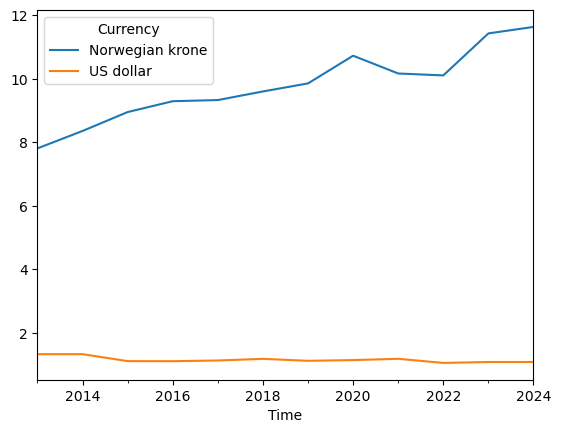

In [6]:
#data = response.json() #IKKE til jsonstat
data = response.text #Jsonstat (pyjstat) vil ha råtekst

dataset = pyjstat.Dataset.read(data)

#Lest til dataframe
df = dataset.write("dataframe")
df["Time frequency"].unique() # Kun 1 verdi
df["Statistical information"].unique()# Kun 1 verdi
df["Unit of measure"].unique()# Kun 1 verdi
df["Currency"].unique()
df["Time"] = pd.to_datetime(df["Time"])
df_pivot = df.pivot(columns="Currency", index="Time", values="value")

df_pivot[["Norwegian krone", "US dollar"]].plot()